### 使用挪威北海数据训练的模型，直接应用预测中海油油服的数据

In [18]:
!pwd  #查看所在的文件夹
%load_ext autoreload
%autoreload 2

import time
import torch
import random
import numpy as np
import torch_geometric as tg
import os
import pandas as pd
import argparse
import torch_geometric.loader as loader
from matplotlib import pyplot as plt

from utils_AIgeo import *
from load_data_AIgeo import *
from model_AIgeo import *

import sys 
sys.path.append('/home/cldai/sciresearch/logcomplete')
from utils.plot_cat_sam import *
from utils.gardner import *
from utils.my_corr_eva import *
from utils.paper_fig import *

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

/home/cldai/sciresearch/logcomplete/code/FlexLogNet_AIgeo10_17
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
#jupyter 不运行argparser，把argparser改写成Param的字典形式就好，  ""
param = {}


# param['filePath'] = '/home/cldai/sciresearch/logcomplete/data/Teamdata/AIgeo_data/standard/'  #固定
# param['filePath'] = '/home/cldai/sciresearch/logcomplete/data/AIgeo/select_filt_clean/'  #固定
param['filePath'] = '/home/cldai/sciresearch/logcomplete/data/AIgeo_1017_process/'  #固定



## "AI_geo_two_wells_norm_by_norway_mean_std.csv" #'AI_geo_two_wells.csv'
## well2_AI_geo_two_wells_DTC_normd_by_norway.csv
param['set_name'] =  "all_z_norm_by_norway.csv"       ##需改
print('测试的数据集是否正确：', param['set_name'])
# print("======= 使用训练集数据！！！！")

param['path'] = '/home/cldai/sciresearch/logcomplete/model/AIgeo/'   #固定
param['save_model_path'] = param['path']
#param['model_name'] = '10.18_exp4_best_489epo.pth' #'best_107epo.pth' #'8.6_xyz_550.pt'  #norway预训练'best_1082epo.pth'  ##需改
param['model_name'] = "10.18_exp4_best_289epo.pth"

print("模型路径及名称", param['save_model_path']+param['model_name'])

param['mask_logs'] = ['RHOB']  ##需改
print('掩盖需要预测的log是：', param['mask_logs'])

# param['bilstm_pred_path'] = param['path']+'Bilstm/'+param['set_name'][:5]+'_'+param['mask_logs'][0][:]+'_pred_data/'  #自动更改
# print('注意检查bilstm数据读取路径是否正确:', param['bilstm_pred_path'])

param['GNN_Bilstm_pred'] = param['save_model_path']+param['mask_logs'][0][:]+'_pred_data/'   ##自动更改 
if not os.path.exists(param['GNN_Bilstm_pred']):
    os.makedirs(param['GNN_Bilstm_pred'])
param['fig_path'] = param['save_model_path']+param['mask_logs'][0][:]+'_fig/'  ##自动更改 
if not os.path.exists(param['fig_path']):
    os.makedirs(param['fig_path'])
print('GNN预测井结果 保存路径：', param['GNN_Bilstm_pred'])
print('GNN预测井图片 保存路径：', param['fig_path'])

param['dataset_for_result'] = 'test'  #'test:用测试集; val:用验证集; train:用训练集看效果'

param['label_intact'] = True  ##现在要用MyGNNDataset_cat_sam，所以label_intact无论什么数据都=True没关系
param['plot_Gardner'] = False
param['sam_fixed'] = True  #样本‘选择性‘固定  #class MyGNNDataset_cat_sam(gdata.Dataset)中所需
# param['all_mean'] = np.array([71.38444259, 2.28596682, 0.33244899, 113.28539098])
# param['all_std'] = np.array([22.58998274, 0.21672449, 0.10531198, 27.63277418])
# param['all_mean'] = np.array([0, 0, 0, 0])
# param['all_std'] = np.array([1, 1, 1, 1])

###油服两口井的均值方差
# param['all_mean'] = np.array([1.15400062e+02, 8.69547275e-02, 1.85507909e+00, 0])
# param['all_std'] = np.array([26.25310153, 0.1066598, 2.00705623, 1])

##挪威所有井的均值和方差   GR RHOB RDEP DTC
param['all_mean'] = np.array([70.42384286, 2.29097466, 10.70237874, 112.78768906])
param['all_std'] = np.array([33.3290957, 0.2442847, 105.03296023, 29.52836293])

### 挪威所有井七类别曲线的均值和方差
# Index(['GR', 'RHOB', 'NPHI', 'DTC', 'RDEP', 'RMED', 'RSHA'],
# np_mean (1, 7) [[ 70.42384286   2.29097466   0.32889002 112.78768906   10.70237874
#     4.44677677  10.82893821]]
# np_std (1, 7) [[ 33.3290957    0.2442847    0.1257481   29.52836293 105.03296023
#    49.20864417 103.56441903]]


param['multi_ch'] = True  #根据输入数据是否为多通道数据决定，影响后面plot的数据选择
param['data_norm_type'] = ''  #数据归一化的类型,按样本(sample)每个分别归一化或者按每口井(well)归一化
param['graph_channels'] = [512,256,128,64,32]  #"Channels of graphunet in each layers"
param['sam_len'] = 512  #length of every sample
param['null_sequence'] = True  #True对应某整个序列赋为空值,否则序列的部分片段赋为空值
param['reverse_norm'] = True  #是否要进行反归一化
param['fea_litho'] = ['GR', 'RHOB', 'NPHI', 'DTC']  #feature and lithology that we need
param['plot_figure'] = True  #If plot figure for test
param['filt_size'] = 19  #中值滤波的窗口大小，只可为奇数   #original=7
param['drop'] = 0  #网络的dropout
param['head'] = 1
param['pnl'] = False  #pnl:pred(need)_label。true：第三张图画pred_need_label，即需要预测的和label，False:画整条预测和label
param['has_w'] = False  #w可视化，看有没有输出要可视化
param['batch_size'] = 1  #batch size
param['sam_num'] = 1  #the number of sample in every set

测试的数据集是否正确： all_z_norm_by_norway.csv
模型路径及名称 /home/cldai/sciresearch/logcomplete/model/AIgeo/10.18_exp4_best_289epo.pth
掩盖需要预测的log是： ['RHOB']
GNN预测井结果 保存路径： /home/cldai/sciresearch/logcomplete/model/AIgeo/RHOB_pred_data/
GNN预测井图片 保存路径： /home/cldai/sciresearch/logcomplete/model/AIgeo/RHOB_fig/


## 加载模型和模型参数
* 1

## 加载数据

In [20]:
if param['dataset_for_result'] == 'val':
    print('用 验证集 数据看效果')
    dfval=pd.read_csv(param['filePath'] +'',engine='python')  #val_standard.csv
    
    all_well_name=dfval['WELL'].unique() 
    all_well_name_r= all_well_name
    print('all_well_name_r',all_well_name_r)
    
    #取出井看每一口井的长度
    all_well_len = dfval.groupby('WELL', sort=False).size()
    print('all_well_len',all_well_len)  #all_well_len is Series
    num_siw = np.array(all_well_len/param['sam_len'],dtype=int)  #num_siw is num_sam_in_well
    print('每口井中样本的个数',num_siw)
    
elif param['dataset_for_result'] == 'train':
    print('用 训练集 数据看效果')
    dfTrain=pd.read_csv(param['filePath'] +'',engine='python')  #train_standard.csv
    
    all_well_name=dfTrain['WELL'].unique() 
    all_well_name_r= all_well_name
    print('all_well_name_r',all_well_name_r)
    
    all_well_name_r=[]
    for i in range(len(all_well_name)):
        r = all_well_name[i].replace('/','-') 
        all_well_name_r .append(r)
    print('all_well_name',all_well_name)  
    print('all_well_name_r',all_well_name_r)
    
    #取出井看每一口井的长度
    #sort=False使groupby不按index排序，避免改变原index顺序
    all_well_len = dfTrain.groupby('WELL', sort=False).size()
    print('all_well_len',all_well_len)  #all_well_len is Series
    num_siw = np.array(all_well_len/param['sam_len'],dtype=int)  #num_siw is num_sam_in_well
    print('每口井中样本的个数',num_siw)
    
else:
    print('用 测试集 数据看效果')
    print('缺失的feature为：',param['mask_logs'])
    dfTest=pd.read_csv(param['filePath'] + param['set_name'],engine='python')   #test_standard.csv
    
    dfTest = dfTest[['WELL','DEPTH_MD','GR', 'RHOB', 'RDEP', 'DTC']].copy()
    dfTest = dfTest.rename(columns={'RDEP':'NPHI'})
    print('RDEP列名改为NPHI')
    
    print("dfTest.head()", dfTest.head())

    all_well_name=dfTest['WELL'].unique() 
    all_well_name_r= all_well_name
    
    all_well_name_r=[]
    for i in range(len(all_well_name)):
        r = all_well_name[i].replace('/','-') 
        all_well_name_r.append(r)
    print('all_well_name',all_well_name)  
    print('all_well_name_r',all_well_name_r)
    
    #取出井看每一口井的长度
    all_well_len = dfTest.groupby('WELL', sort=False).size()
    print('all_well_len',all_well_len)  #all_well_len is Series
    num_siw = np.array(all_well_len/param['sam_len'],dtype=int)  #num_siw is num_sam_in_well
    print('每口井中样本的个数',num_siw)
    
#mean_log=pd.read_csv(param['filePath']+'train_logs_mean.csv')


用 测试集 数据看效果
缺失的feature为： ['RHOB']
RDEP列名改为NPHI
dfTest.head()           WELL  DEPTH_MD        GR  RHOB  NPHI  DTC
0  4-16IN-SLAM   152.444 -2.246386   NaN   NaN  NaN
1  4-16IN-SLAM   152.596 -2.210136   NaN   NaN  NaN
2  4-16IN-SLAM   152.748 -2.167696   NaN   NaN  NaN
3  4-16IN-SLAM   152.900 -2.131511   NaN   NaN  NaN
4  4-16IN-SLAM   153.052 -2.120221   NaN   NaN  NaN
all_well_name ['4-16IN-SLAM' '5_12.25in_RUN2A_SLAM_2205.72-3778.45m_MAIN'
 '4_12.25IN_XDT-ALT-MAIN' '2-14.625IN-SLAM'
 '8_12.25in_RUN1_RUN1A_ALT-XDT_2003.6-3749.5m_MAIN'
 '5_16in_WL_RUN1A_SLAM_1550-2057.33m_MIAN']
all_well_name_r ['4-16IN-SLAM', '5_12.25in_RUN2A_SLAM_2205.72-3778.45m_MAIN', '4_12.25IN_XDT-ALT-MAIN', '2-14.625IN-SLAM', '8_12.25in_RUN1_RUN1A_ALT-XDT_2003.6-3749.5m_MAIN', '5_16in_WL_RUN1A_SLAM_1550-2057.33m_MIAN']
all_well_len WELL
4-16IN-SLAM                                         10830
5_12.25in_RUN2A_SLAM_2205.72-3778.45m_MAIN          10594
4_12.25IN_XDT-ALT-MAIN                              12033
2-1

In [21]:
def prediction_label_input(test_loader_n):
        predictions = []
        labels = []
        inputdatas = []
        mask0s = []
        maskds = []
        label_intacts = []
        md_staps = []
        md_endps = []
        # norm_means = []
        # norm_stds = []

        
        #print('len(test_loader_n)',len(test_loader_n))
        for data in test_loader_n:
            inputdata = data.x.detach().cpu().numpy()
            
            if param['has_w'] == True:
                pred, _ = model(data)
                pred = pred.detach().cpu().numpy() 
            else:
                pred, mean, std =  model(data)
            
            pred = pred.detach().cpu().numpy()
            label = data.y.detach().cpu().numpy()
            mask0 = data.mask.detach().cpu().numpy()
            maskd = data.maskd.detach().cpu().numpy()
            md_stap = data.md_stap.detach().cpu().numpy()
            md_endp = data.md_endp.detach().cpu().numpy()
            mean = mean.detach().cpu().numpy()
            std = std.detach().cpu().numpy()
            mean = np.reshape(mean,(4,1))
            std = np.reshape(std,(4,1))
            
            label_mean = data.norm_mean.detach().cpu().numpy()
            label_std = data.norm_std.detach().cpu().numpy()
            
            if param['label_intact']==True:
                label_intact = data.label_intact.detach().cpu().numpy()
                label_intact = label_intact *np.reshape(param['all_std'],(4,1)) + np.reshape(
                                param['all_mean'],(4,1))

            print('mean.shape',mean.shape)
            pred = pred*std+mean
            #print('反归一化后pred.shape',pred.shape)
            pred = pred*np.reshape(param['all_std'],(4,1)) + np.reshape(param['all_mean'],(4,1))
            print('按全井反归一化后pred.shape', pred.shape)
            
            inputdata = inputdata*np.reshape(label_std,(4,1,1))+ np.reshape(label_mean,(4,1,1))
            #print('反归一化后inputdata.shape',inputdata.shape)
            inputdata = inputdata*np.reshape(param['all_std'],(4,1,1))+ np.reshape(
                        param['all_mean'],(4,1,1))
            
            label = label*np.reshape(label_std, (4,1))+np.reshape(label_mean, (4,1))
            label = label*np.reshape(param['all_std'],(4,1)) + np.reshape(param['all_mean'],(4,1))
            
            
            predictions.append(pred)  #将numpy数组append进list里，pred:[array[[64长度]...[] (7*64)] ]
            labels.append(label)
            inputdatas.append(inputdata)
            mask0s.append(mask0)
            maskds.append(maskd)
            md_staps.append(md_stap)
            md_endps.append(md_endp)
            # norm_means.append(norm_mean)
            # norm_stds.append(norm_std)
            
            if param['label_intact']==True:
                label_intacts.append(label_intact)

        predictions=np.array(predictions)  #shape[[[]]]  #shape:(sam_num/batch_size, 7*batch_size, 64)
        labels=np.array(labels)
        inputdatas=np.array(inputdatas)
        mask0s=np.array(mask0s)
        maskds=np.array(maskds)
        md_staps = np.array(md_staps)
        md_endps = np.array(md_endps)


        if param['label_intact']==True:
            label_intacts= np.array(label_intacts)
            return predictions, labels, inputdatas, mask0s, maskds, label_intacts,  md_staps,md_endps
        else:    
            return predictions, labels, inputdatas, mask0s, maskds, md_staps,md_endps,

In [22]:
#加载模型
model = GraphNet(param['graph_channels'],param['batch_size'],param['fea_litho'],param['head'],param['drop'])
load_model_name_phase = param['save_model_path'] +param['model_name'] 
'''torch.load加载模型，map_location=cpu,Load all tensors onto the CPU. 加上了['net']，则仅加载了net,save_model时中其他的参数没加载'''
param_model = torch.load(load_model_name_phase,map_location='cpu')['net']  
#param_model = torch.load(load_model_name_phase)['net']
#model.load_state_dict(param_model)  #加载模型参数
model.load_state_dict({k.replace('module.',''):v for k,v in param_model.items()})

！！！！！！！！！！！注意 不聚合的网络中device： cpu
！！！！！！！！！！！注意 不聚合的网络中device： cpu
！！！！！！！！！！！注意 不聚合的网络中device： cpu
！！！！！！！！！！！注意 不聚合的网络中device： cpu
！！！！！！！！！！！注意网络中device： cpu
！！！！！！！！！！！注意网络中device： cpu
！！！！！！！！！！！注意网络中device： cpu
！！！！！！！！！！！注意网络中device： cpu


<All keys matched successfully>

## 预测训练集或验证集的井

掩盖的log类型是： ['RHOB']
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 0
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 512
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 1024
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 1536
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 2048
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 2560
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 3072
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 3584
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 4096
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 4608
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 5120
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label

/home/cldai/sciresearch/logcomplete/utils/my_corr_eva.py:81: RuntimeWarning: Mean of empty slice.
  eva = np.sqrt(((d[0, :] - d[1, :]) ** 2).mean())
/home/cldai/anaconda3/envs/geom2.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


选取的起始点： 0
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 512
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 1024
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 1536
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 2048
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 2560
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 3072
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 3584
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 4096
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 4608
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 5120
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 5632
mean.shape (

/home/cldai/sciresearch/logcomplete/utils/my_corr_eva.py:81: RuntimeWarning: Mean of empty slice.
  eva = np.sqrt(((d[0, :] - d[1, :]) ** 2).mean())
/home/cldai/anaconda3/envs/geom2.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


选取的起始点： 0
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 512
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 1024
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 1536
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 2048
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 2560
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
label_mask0函数中必须设置RHOB初始掩码！！！
选取的起始点： 3072
mean.shape (4, 1)
按全井反归一化后pred.shape (4, 512)
======  [1490.472] [1490.472]
======  [2035.088] [2035.088]
画5_16in_WL_RUN1A_SLAM_1550-2057.33m_MIAN井
len(lis) 4
预测效果图保存的是reversed2的路径！
df_dtc.shape (3584, 2)
下面看去除nan值后的相关系数和交汇图
dtc_dna.shape (3462, 2)
rb_corr, nphi_corr, dtc_corr          label     pred
label  1.00000  0.87353
pred   0.87353  1.00000           label      pred
label  1.000000 -0.092411
pred  -0.092411  1.000000           label      pred
lab

<Figure size 2400x4800 with 0 Axes>

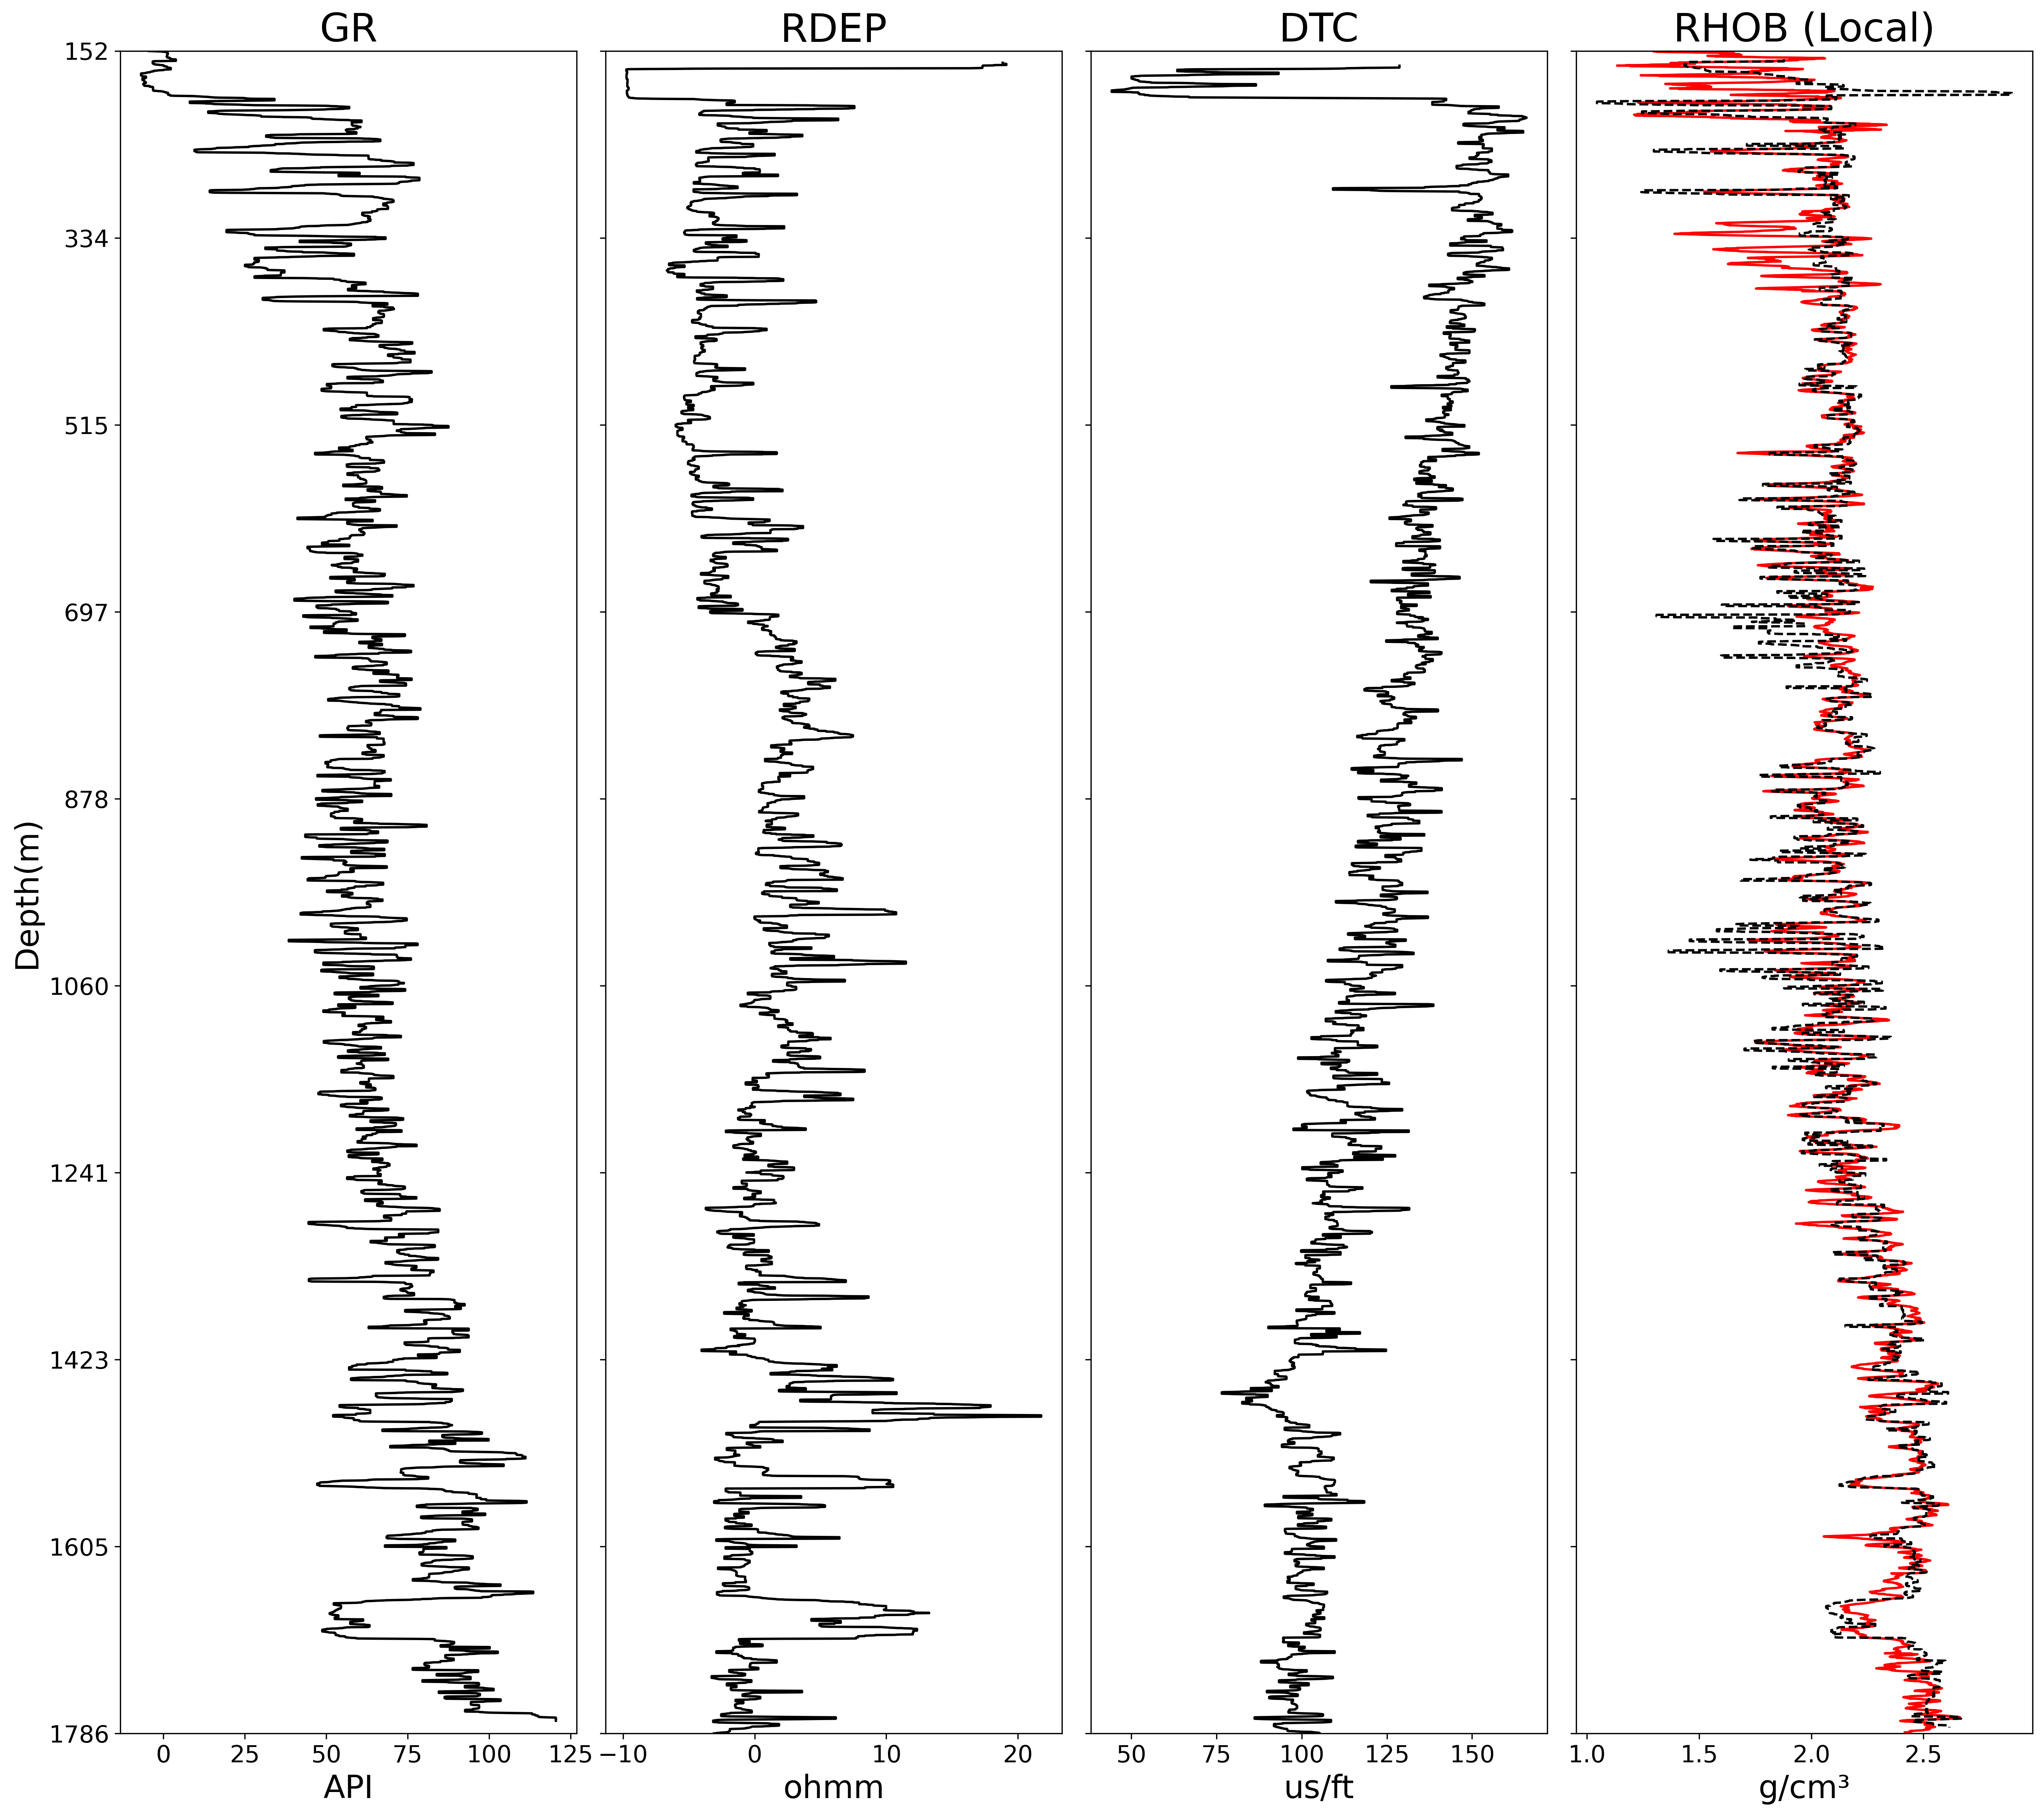

<Figure size 2400x4800 with 0 Axes>

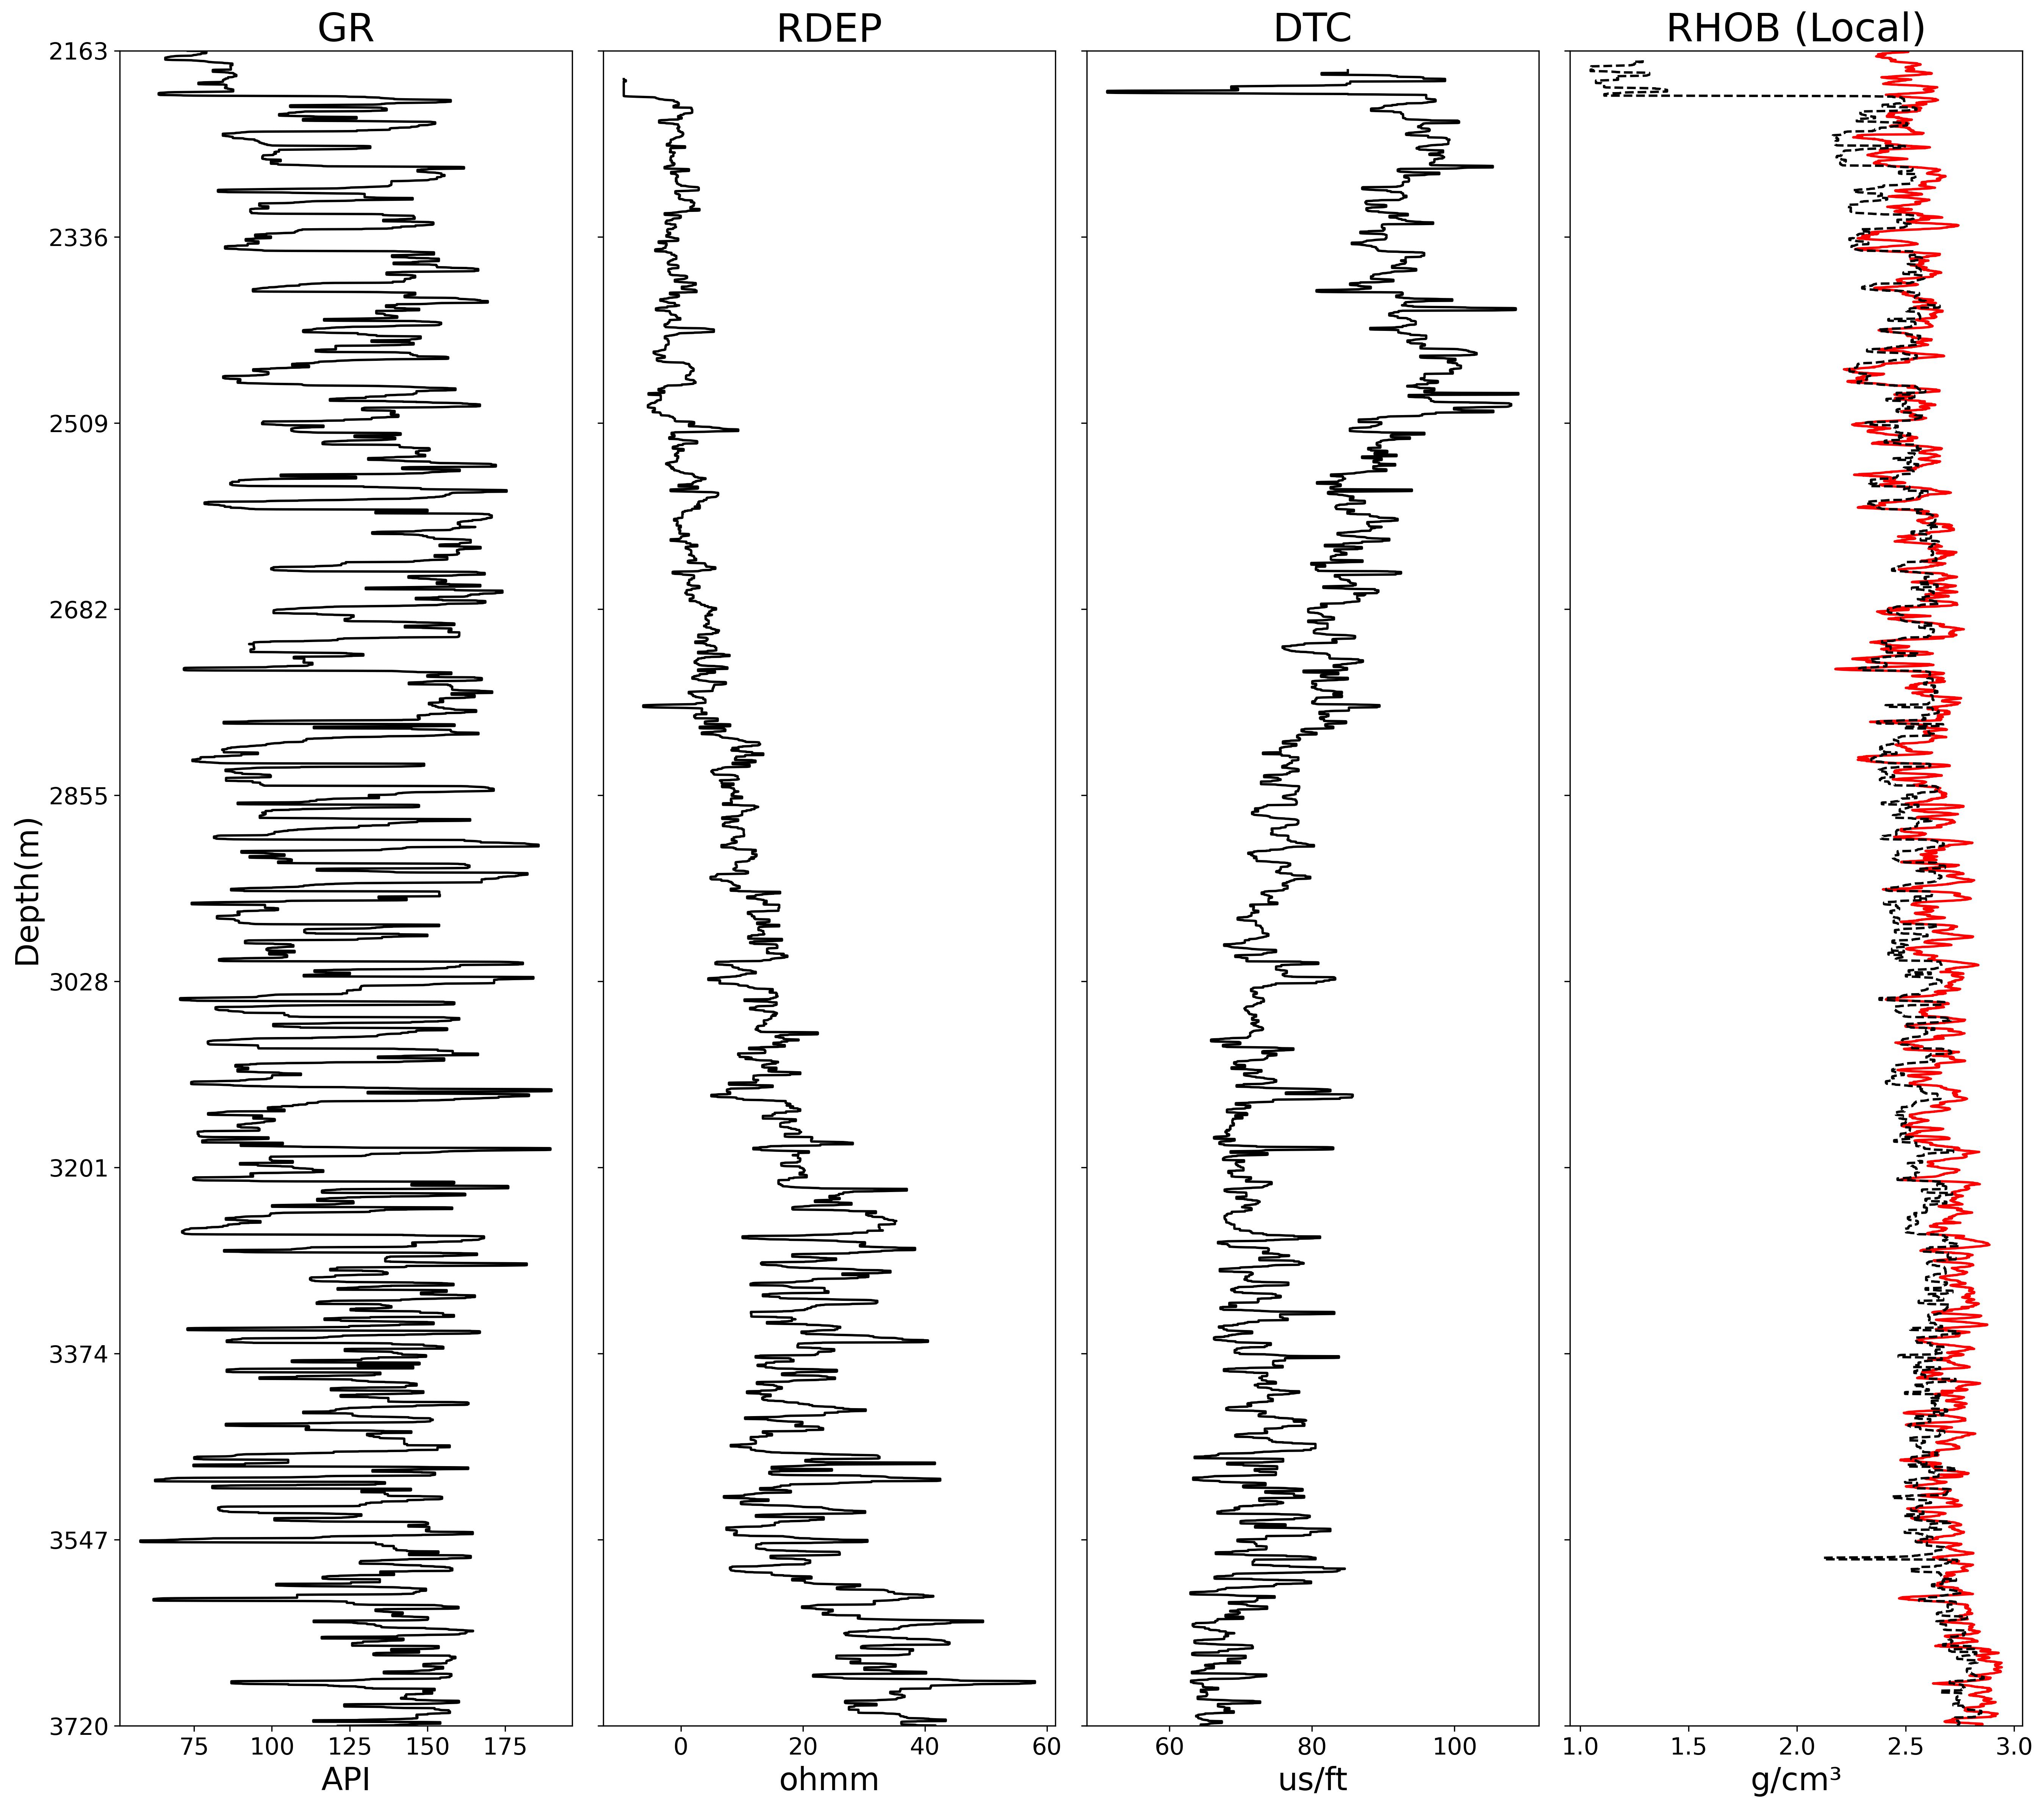

<Figure size 2400x4800 with 0 Axes>

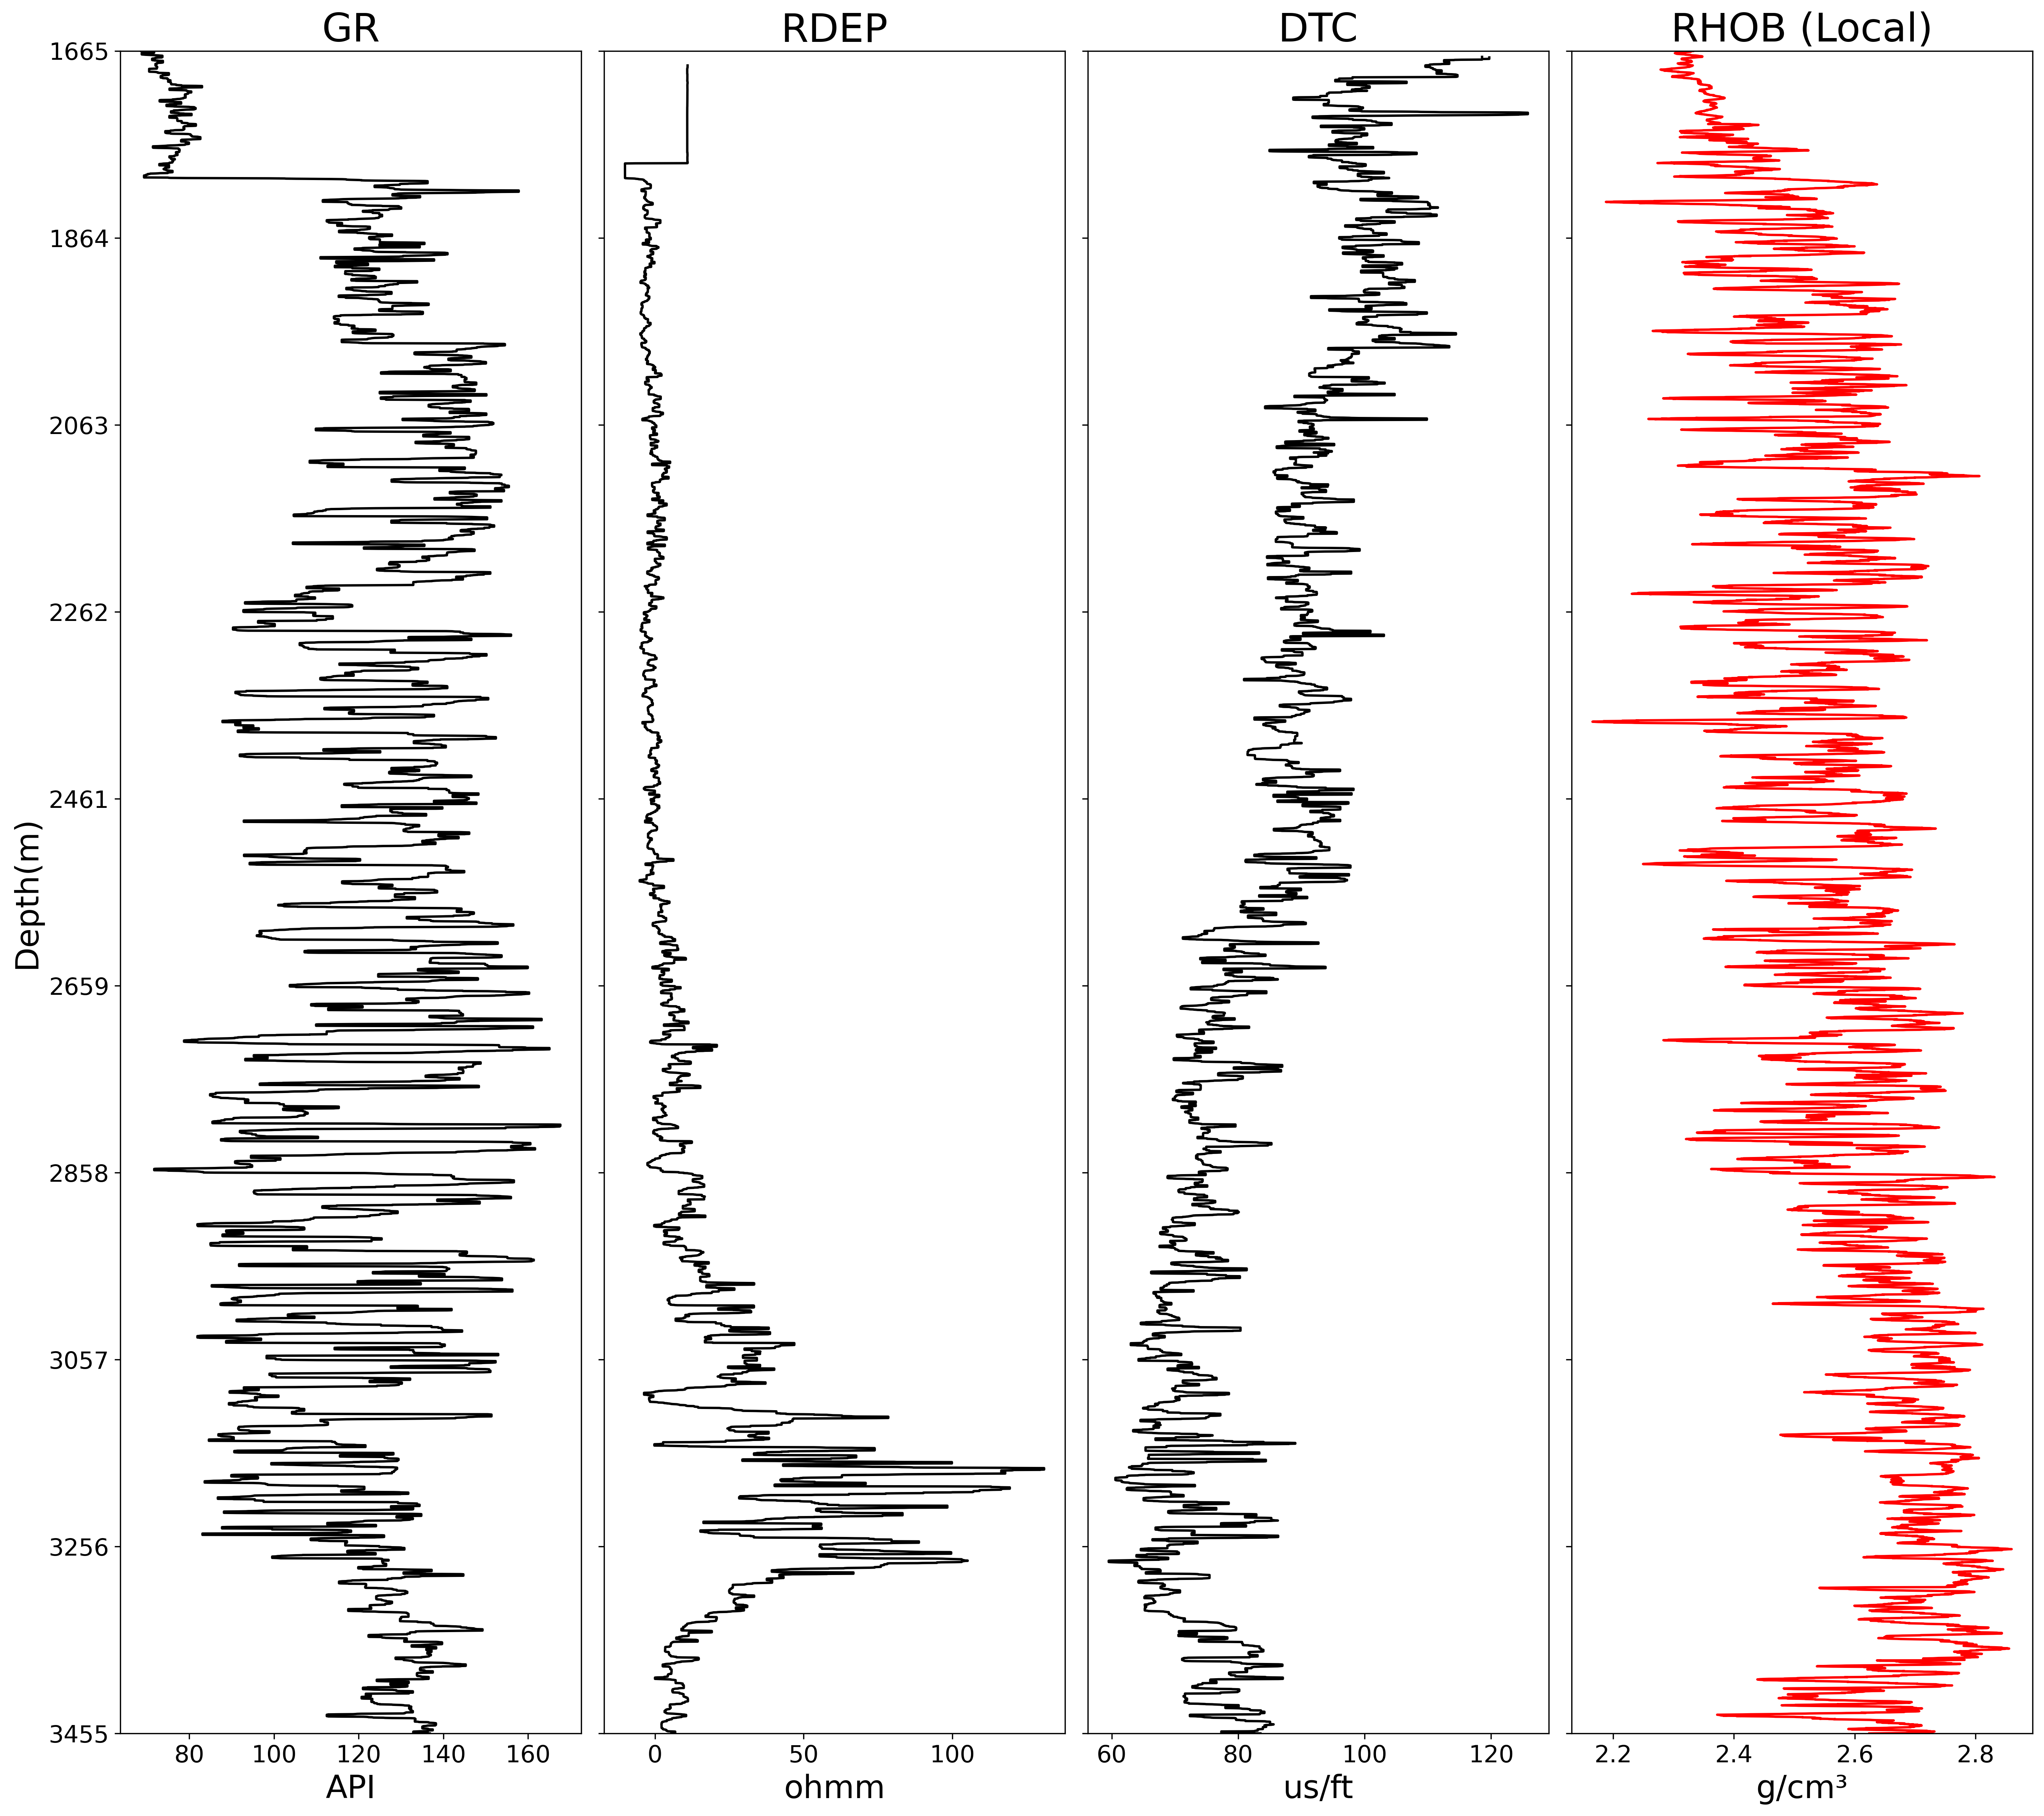

<Figure size 2400x4800 with 0 Axes>

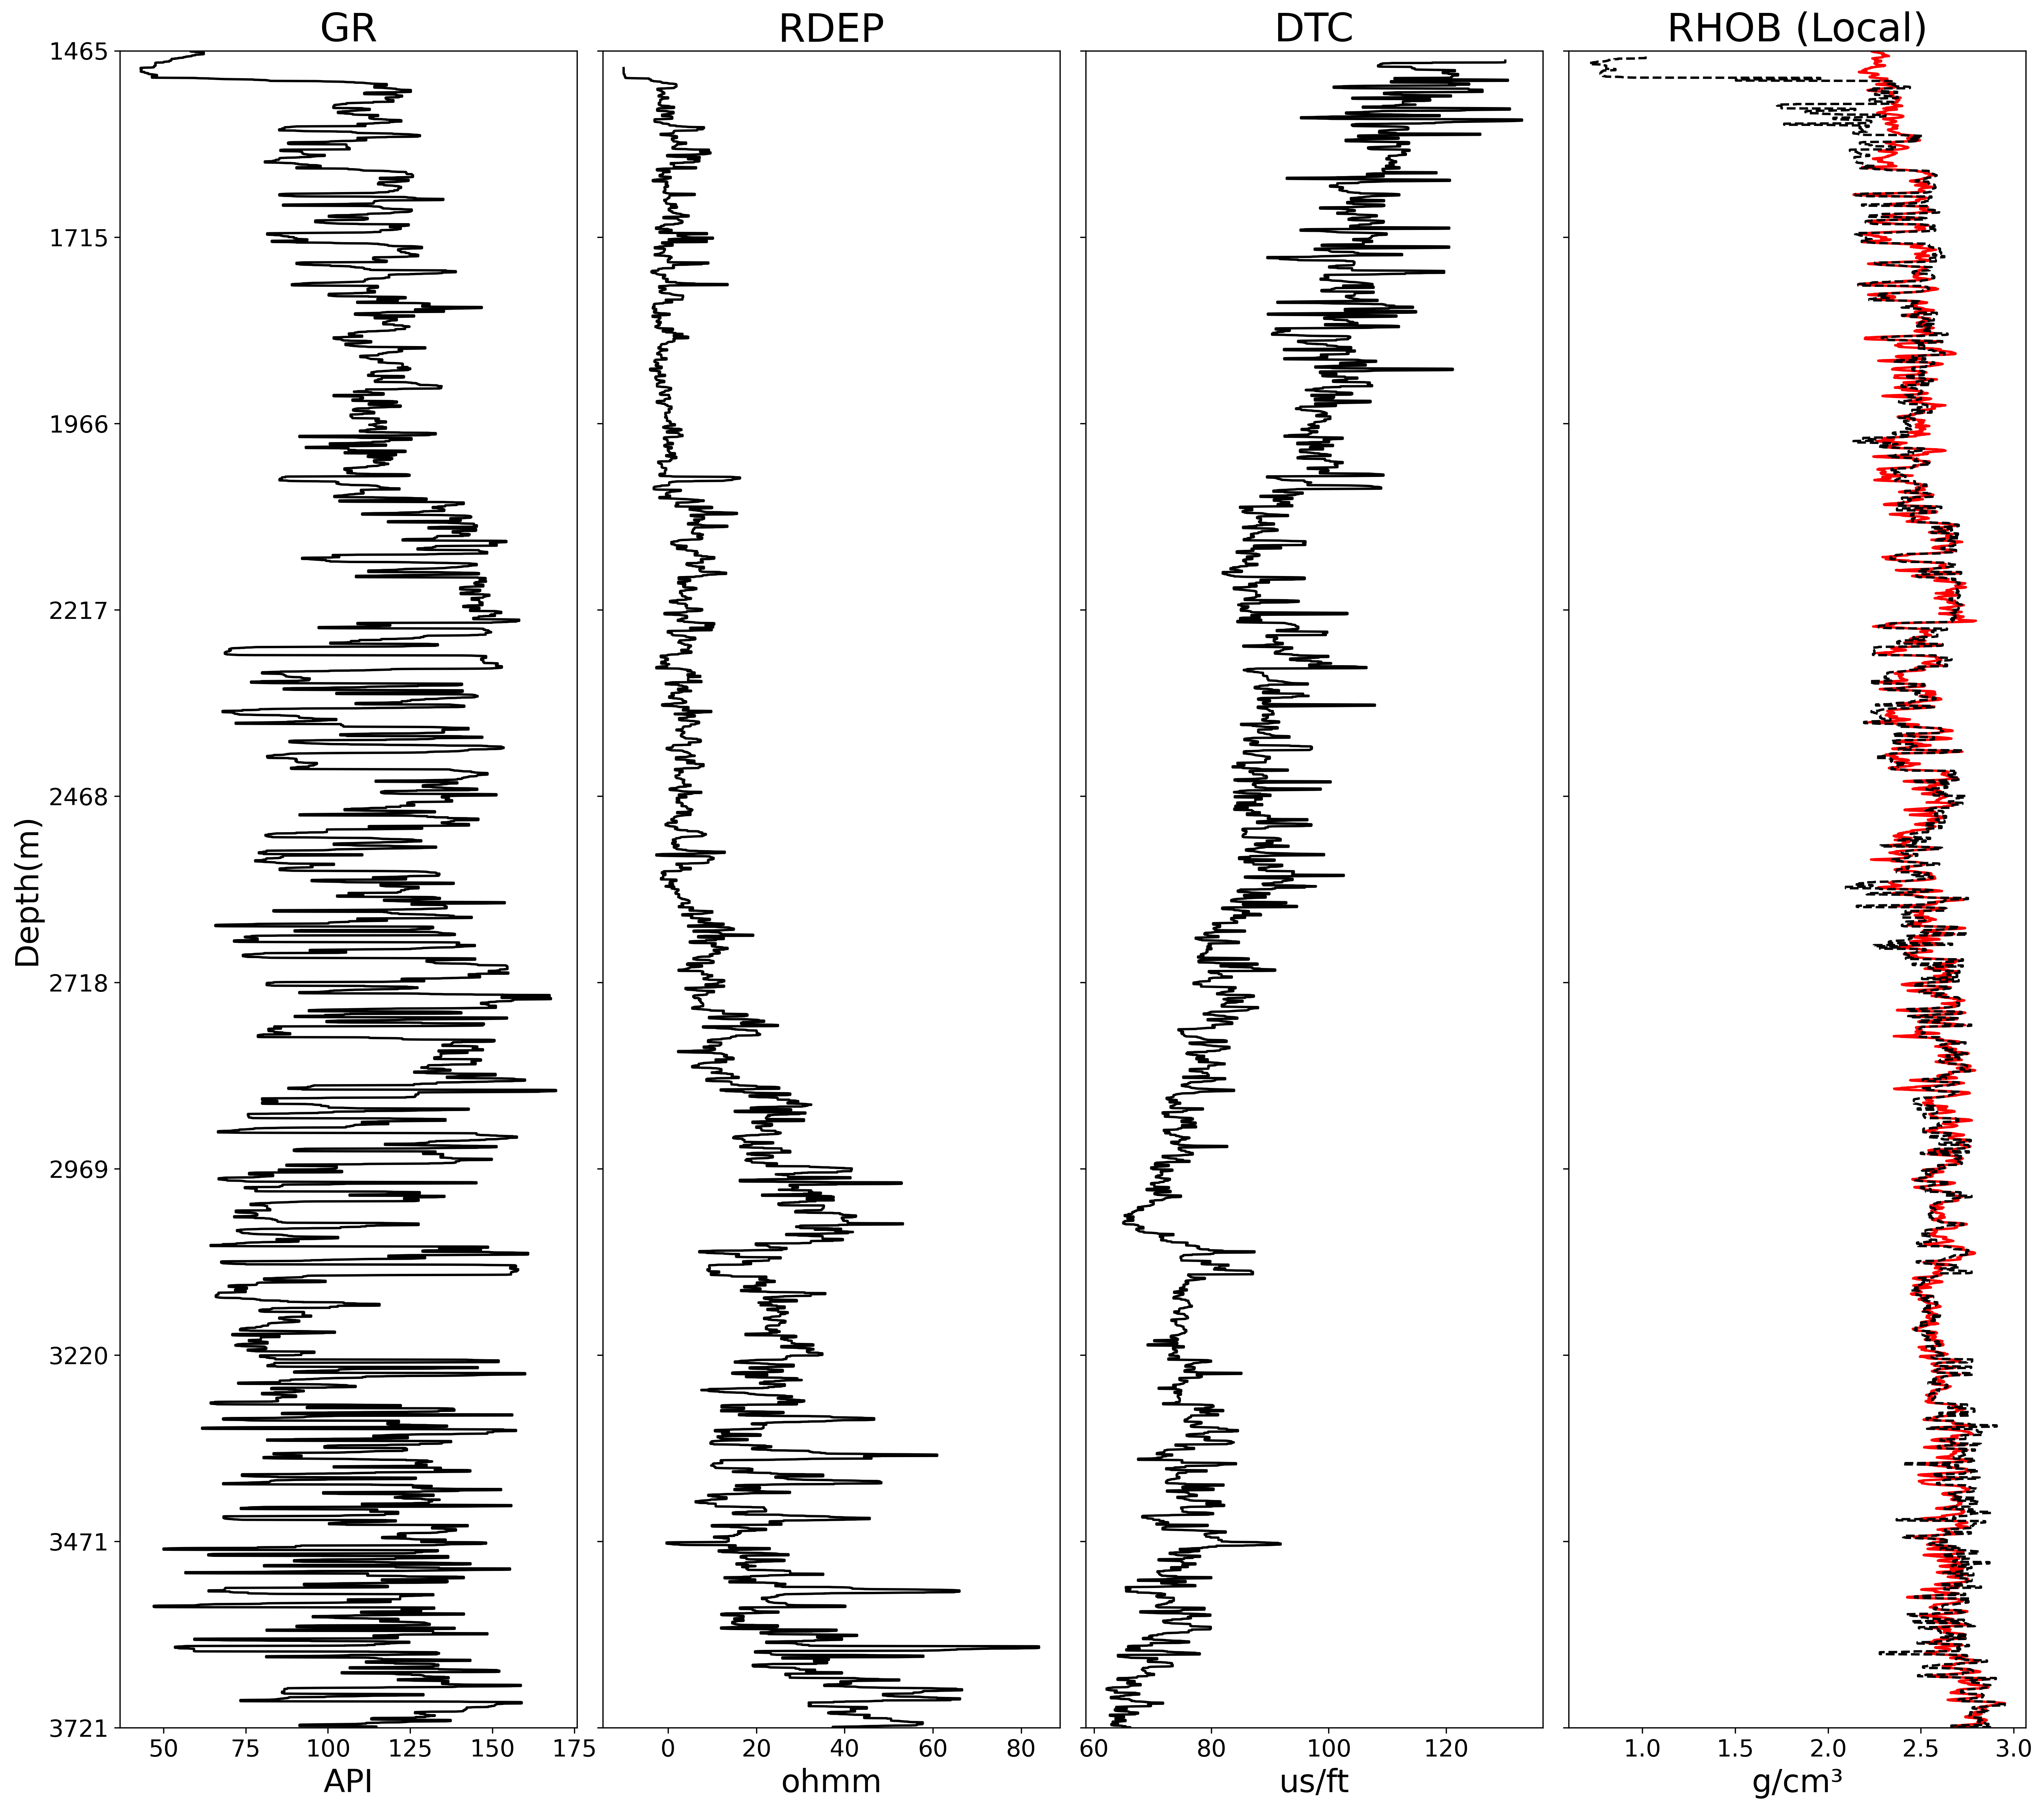

<Figure size 2400x4800 with 0 Axes>

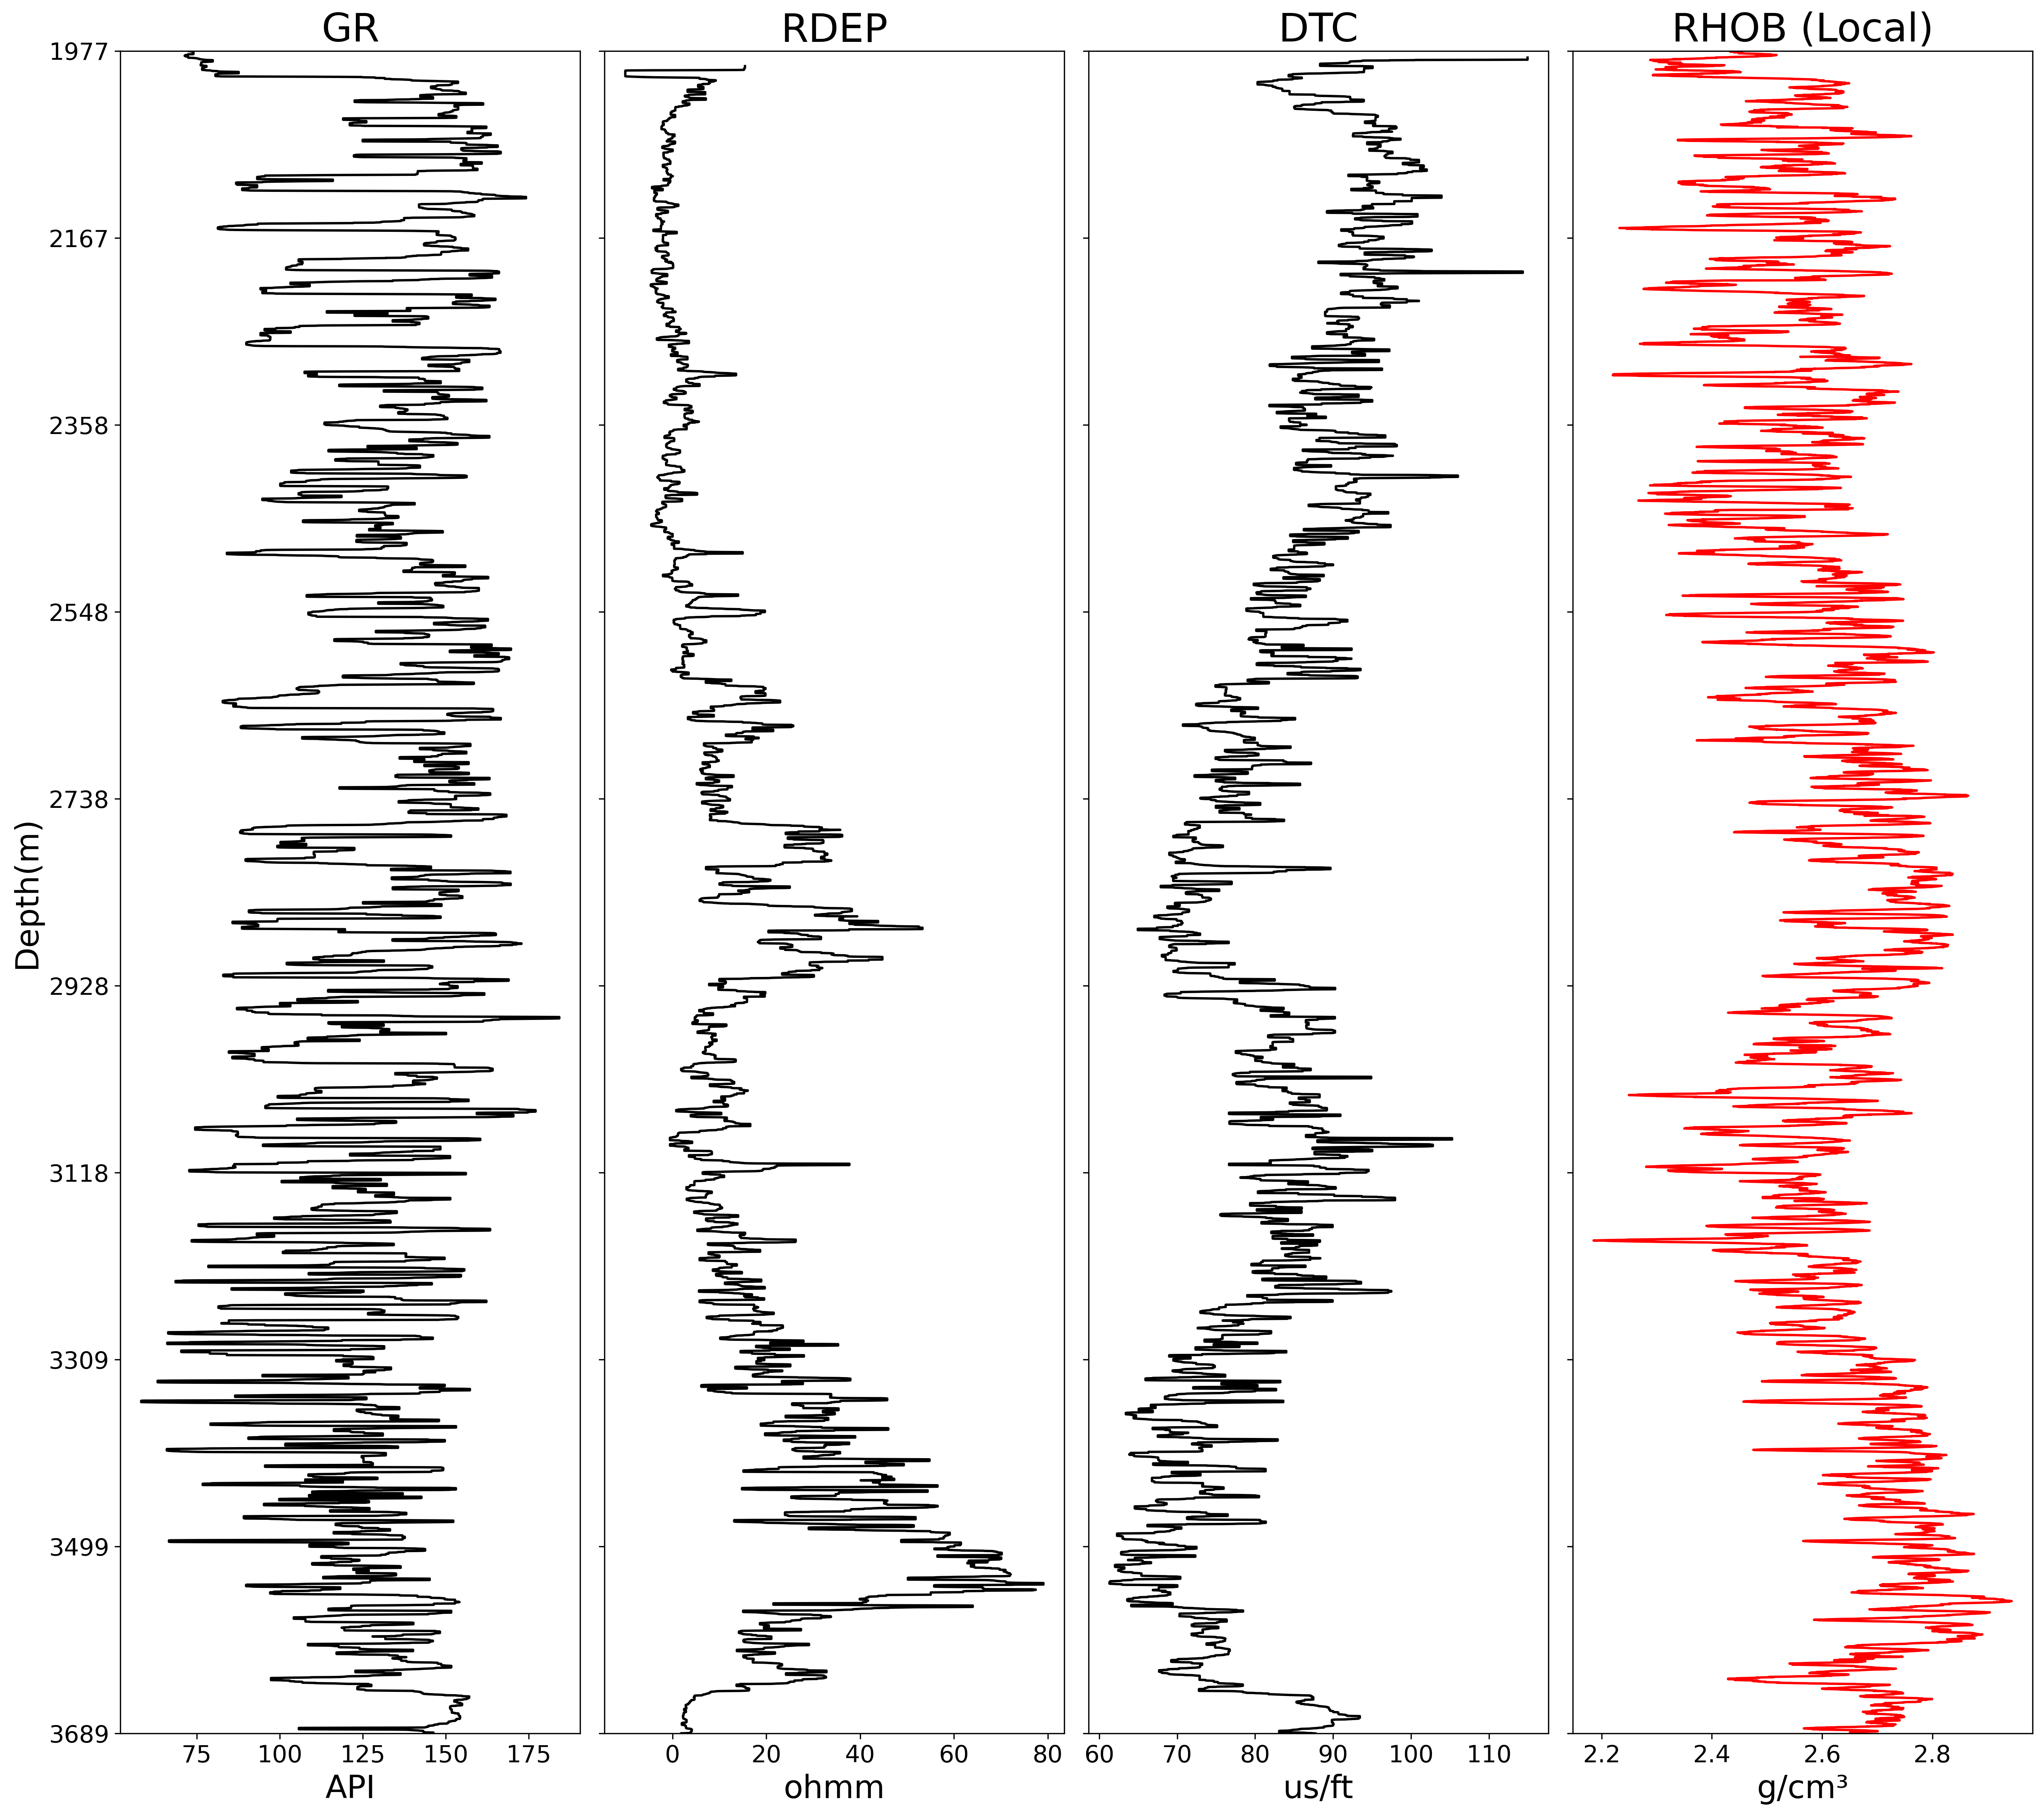

<Figure size 2400x4800 with 0 Axes>

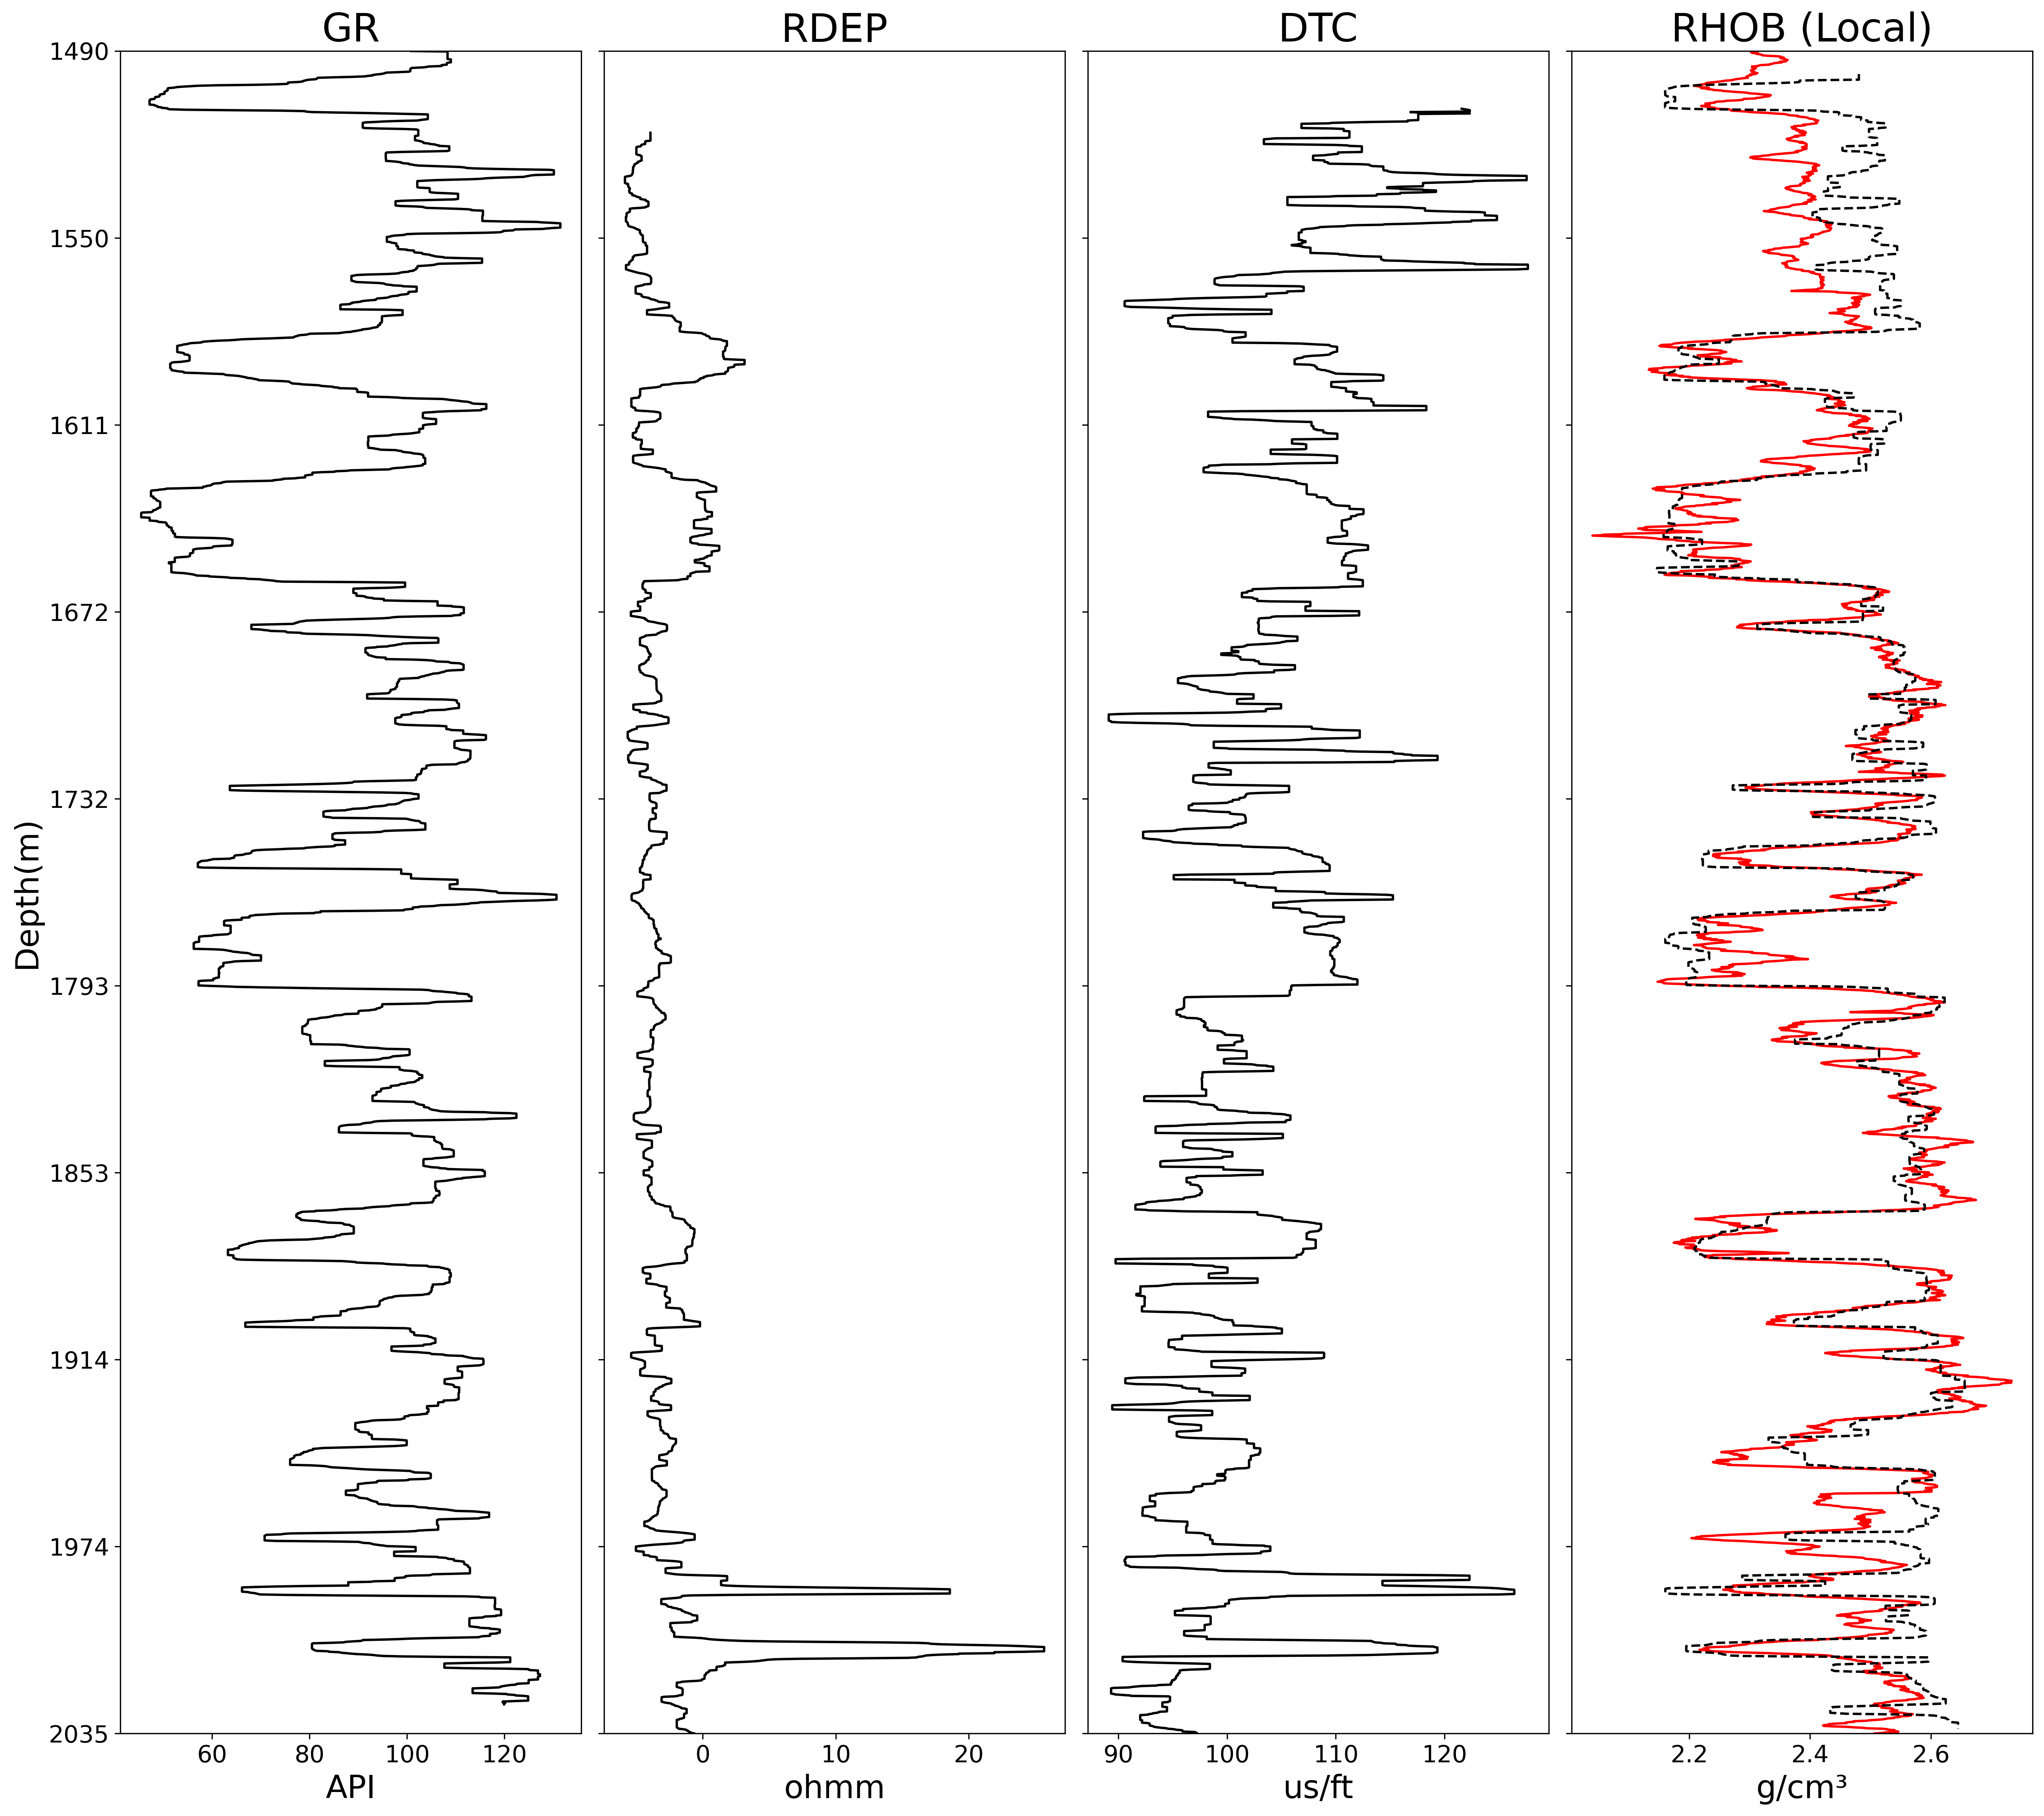

In [23]:
print('掩盖的log类型是：',param['mask_logs'])

well_MSE_list = []
bilstm_MSE_list = []
Gardner_RMSE_list = []
GNN_pear = []
Bilstm_pear = []
Gardner_pear = []

for wo in range(6):
#for wo in range(0, 96, 6):   #wo is well order
    #取10口井查看效果，
    #每口井中样本的个数 [21 22 19 33 21 17 15 23 42 20] all_well_name ['15/9-23' '16/2-7' '16/7-6' '17/4-1' '25/10-9' '31/2-10' '31/2-21 S' '34/3-2 S' '35/11-5' '35/9-7']
    #拼接取到的样本
    label = np.zeros((len(param['fea_litho']),param['sam_len']*num_siw[wo]))
    label_intact = np.zeros((len(param['fea_litho']),param['sam_len']*num_siw[wo]))
    input = np.zeros((len(param['fea_litho']),4,param['sam_len']*num_siw[wo]))  #4 表示4通道
    pred =  np.zeros((len(param['fea_litho']),param['sam_len']*num_siw[wo]))
    mask0 = np.zeros((len(param['fea_litho']),param['sam_len']*num_siw[wo]))
    maskd = np.zeros((len(param['fea_litho']),param['sam_len']*num_siw[wo]))

    for so in range(num_siw[wo]):  #so is sam order 表示可取到的样本在井中序号
        #print('so',so)
        if param['dataset_for_result'] == 'train':
            #print('用train数据集来看多个样本效果')
            fix_stap = so*param['sam_len']
            #print('fix_stap',fix_stap)
            wep = param['sam_len']*num_siw[wo]-1  #减去1是因为取不到最后一个 #wep=well_end_point
            #print('wep',wep)
            test_dataset = MyGNNDataset_cat_sam(dfTrain,param['sam_len'],param['sam_num'],param['fea_litho'],param['data_norm_type'],
                                                param['mask_logs'],param['null_sequence'],param['sam_fixed'],param['filt_size'],
                                                wo,wep,fix_stap)
        if param['dataset_for_result'] == 'val':
            print('用val数据集来看多个样本效果')
            fix_stap = so*param['sam_len']
            #print('fix_stap',fix_stap)
            wep = param['sam_len']*num_siw[wo]-1  #减去1是因为取不到最后一个 #wep=well_end_point
            #print('wep',wep)
            test_dataset = MyGNNDataset_cat_sam(dfval,param['sam_len'],param['sam_num'],param['fea_litho'],param['data_norm_type'],
                                                param['mask_logs'],param['null_sequence'],param['sam_fixed'],param['filt_size'],
                                                wo,wep,fix_stap)
        if param['dataset_for_result'] == 'test':
            #print('用test数据集来看多个样本效果')
            fix_stap = so*param['sam_len']
            #print('fix_stap',fix_stap)
            wep = param['sam_len']*num_siw[wo]-1  #减去1是因为取不到最后一个 #wep=well_end_point
            #print('wep',wep)
            test_dataset = MyGNNDataset_cat_sam(dfTest,param['sam_len'],param['sam_num'],param['fea_litho'],param['data_norm_type'],
                                                param['mask_logs'],param['null_sequence'],param['sam_fixed'],param['filt_size'],
                                                wo,wep,fix_stap)
            #param['sam_len'],fix_stap
        test_loader = loader.DataLoader(test_dataset, batch_size=param['batch_size'],num_workers=1)
        '''上述test_dataset和test_loader用到了MyGNNDataset_test_whole_well、DataLoader，但这里只是定义初始化好，
        并没有实际生成数据样本，而是到了下面for data in test_loader_n中调用data时，才开始实际生成数据来调用'''

        if param['label_intact'] == True:  #当用测试集里完整的label时，==True，运行这里
            predictions, labels, inputdatas, mask0s, maskds, label_intacts, md_staps,md_endps = prediction_label_input(test_loader)
            label_intact[:,param['sam_len']*so:param['sam_len']*(so+1)] = label_intacts[0]
            
        else: 
            predictions, labels, inputdatas, mask0s, maskds, md_staps,md_endps = prediction_label_input(test_loader)
        
        label[:,param['sam_len']*so:param['sam_len']*(so+1)] = labels[0]
        pred[:,param['sam_len']*so:param['sam_len']*(so+1)] = predictions[0]
        input[:,:,param['sam_len']*so:param['sam_len']*(so+1)] = inputdatas[0]
            
        mask0[:,param['sam_len']*so:param['sam_len']*(so+1)] = mask0s[0]      #不要搞糊涂了，mask0和maskd是不能*stds[0]+means[0]！！！
        maskd[:,param['sam_len']*so:param['sam_len']*(so+1)] = maskds[0]
    

    ##保存GNN预测出的数据

    """画在一起  MSE可以单独算再比对"""
    ###读取数据
    # bip = pd.read_csv(param['bilstm_pred_path']+all_well_name_r[wo]+'_pred.csv')
    # #print('读取的bilstm的预测', bip)
    # bip_np = np.array(bip)
    # bip_np = bip_np.T  #(1行, 列长=长度)
    
    print("====== ", md_staps[0], md_staps[-1])
    print("====== ", md_endps[0], md_endps[-1])


    print('画{}井'.format(all_well_name_r[wo]))
    if param['plot_figure']==True:
        
        if param['multi_ch'] == True:
            #由于是多通道，经过列表append后，input的shape为(1, 4, 4, 512)
            #print('查看输入的原始第一通道数据',input[:,0,:])
            if param['label_intact']==True:
                #print('input[:,0,:]',input[:,0,:],'pred',pred,'label_intact',label_intact)
                #画log输入及预测结果
#                 plt_cat_sam(input[:,0,:],pred,label_intact,mask0,maskd,
#                             param['fea_litho'],md_staps[0],md_endps[0],param['fig_path'],
#                             all_well_name_r[wo],param['label_intact'],param['pnl'])


                # paper_plt_cat_sam(input[:,0,:],pred,label_intact,mask0,maskd,param['fea_litho'],md_staps[0],
                #                   md_endps[0],param['fig_path'],all_well_name_r[wo],param['label_intact'],
                #                   param['pnl'],param['mask_logs'][0],param['plot_Gardner'],
                                  
                #                   #bilstm_pred=bip_np
                #                   )

                paper_plt_cat_sam(input[:,0,:],pred,label_intact,mask0,maskd,['GR', 'RHOB', 'RDEP', 'DTC'],md_staps[0],
                                  md_endps[0],param['fig_path'],all_well_name_r[wo],param['label_intact'],
                                  param['pnl'],param['mask_logs'][0],param['plot_Gardner'],
                                  
                                  #bilstm_pred=bip_np
                                  )
         
                #计算相关系数,并绘制散点图
                rb_corr, nphi_corr, dtc_corr = whole_well_corr(pred,label_intact,
                                            param['fea_litho'],param['fig_path'],all_well_name_r[wo])
                print('rb_corr, nphi_corr, dtc_corr', rb_corr, nphi_corr, dtc_corr)

                # print("mask_logs是", param['mask_logs'][0])
                # if param['mask_logs'][0]=='RHOB':
                #     rb_pearson = rb_corr.iloc[0,1]
                #     GNN_pear.append(rb_pearson)
                # elif param['mask_logs'][0]=='NPHI':
                #     nphi_pearson = nphi_corr.iloc[0,1]
                #     GNN_pear.append(nphi_pearson)
                # else:
                #     dtc_pearson = dtc_corr.iloc[0,1]
                #     GNN_pear.append(dtc_pearson)
                # ##相关系数计算及存储
                # bilstm_pearson = bilstm_well_corr(bip_np, label_intact, param['fea_litho'], param['mask_logs'][0])
                # Bilstm_pear.append(bilstm_pearson)

                ##计算MSE定量评价指标：GNN的结果
                eva = calculate_MSE(pred,label_intact,param['fea_litho'], param['mask_logs'][0])
                well_MSE_list.append(eva)

                # ##计算MSE定量评价指标：Bilstm的结果
                # print('检验下面函数对于这两个数据是否正确拼接', bip_np.shape, label_intact.shape)
                # bilstm_eva = calculate_MSE(bip_np,label_intact,param['fea_litho'], param['mask_logs'][0], bilstm=True)
                # bilstm_MSE_list.append(bilstm_eva)

                ##存储GNN预测的数据(指定需要的)、Bilstm预测的数据以及对应的标签
                filepath = param['GNN_Bilstm_pred']
                save_pred_label(pred, label_intact, param['fea_litho'], param['mask_logs'][0], md_staps[0],md_endps[0],
                                #bilstm=bip_np.T,
                                path= filepath + all_well_name_r[wo]+'_pred.csv')

               
                # #看Gardner方程的预测效果以及计算相关系数
                # if param['mask_logs'][0] != 'NPHI':
                #     gardner_rhob_rmse, gardner_dtc_rmse, gardner_rb_corr, gardner_dtc_corr = whole_gardner(
                #                         label_intact,param['fea_litho'],md_staps[0],md_endps[0],param['fig_path'],
                #                         all_well_name_r[wo])
                #     if param['mask_logs'][0]=='RHOB':
                #         gardner_rb_pear = gardner_rb_corr.iloc[0,1]
                #         Gardner_pear.append(gardner_rb_pear)
                #         Gardner_RMSE_list.append(gardner_rhob_rmse)
                #     elif param['mask_logs'][0] == 'DTC':
                #         gardner_dtc_pear = gardner_dtc_corr.iloc[0,1]
                #         Gardner_pear.append(gardner_dtc_pear)
                #         Gardner_RMSE_list.append(gardner_dtc_rmse)
                
                # #画paper中阐述工作的图(以32-2-10阐述)
                # plt_state_work(label_intact,param['fig_path'])

# well_name = pd.Series(all_well_name_r)
# MSE_eva = pd.Series(well_MSE_list)
# print('MSE_eva.shape', MSE_eva.shape)
# bilstm_eva = pd.Series(bilstm_MSE_list)
# if param['mask_logs'][0] != 'NPHI':
#     Gardner_eva = pd.Series(Gardner_RMSE_list)

# GNN_pear = pd.Series(GNN_pear)
# Bilstm_pear = pd.Series(Bilstm_pear)
# if param['mask_logs'][0] != 'NPHI':
#     Gardner_pear = pd.Series(Gardner_pear)

# if param['mask_logs'][0] != 'NPHI':
#     df_well = pd.concat([well_name, MSE_eva, bilstm_eva, Gardner_eva,
#                             GNN_pear, Bilstm_pear, Gardner_pear], axis=1) 
#     df_well.columns = ['well_name', 'RMSE_GNN', 'RMSE_bilstm', 'RMSE_Gardner', 
#                        'Pearson_GNN', 'Pearson_bilstm', 'Pearson_Gardner']
# else:
#     df_well = pd.concat([well_name, MSE_eva, bilstm_eva, 
#                             GNN_pear, Bilstm_pear], axis=1) 
#     df_well.columns = ['well_name', 'RMSE_GNN', 'RMSE_bilstm', 'Pearson_GNN', 'Pearson_bilstm']
# df_well.to_csv(filepath+'RMSE_pearson.csv',
#                    index=False, float_format="%.5f")
# print("df_well", df_well)

